In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

_ = np.loadtxt('J0_J141_T300_exocross.xsec')
print(_)
wavenumber, cross_sec = _[:, 0], _[:, 1]

__ = np.loadtxt('J0_J141_T1000_exocross.xsec')
print(__)
wavenumber_, cross_sec_ = __[:, 0], __[:, 1]

[[0.00000000e+00 1.68358813e-24]
 [5.00000000e-01 6.39853493e-24]
 [1.00000000e+00 1.71631814e-23]
 ...
 [1.99990000e+04 2.04131622e-24]
 [1.99995000e+04 1.86350959e-24]
 [2.00000000e+04 1.12284262e-24]]
[[0.00000000e+00 9.46576344e-25]
 [5.00000000e-01 3.16471847e-24]
 [1.00000000e+00 6.90601698e-24]
 ...
 [1.99990000e+04 2.20060511e-23]
 [1.99995000e+04 2.00207070e-23]
 [2.00000000e+04 1.20109646e-23]]


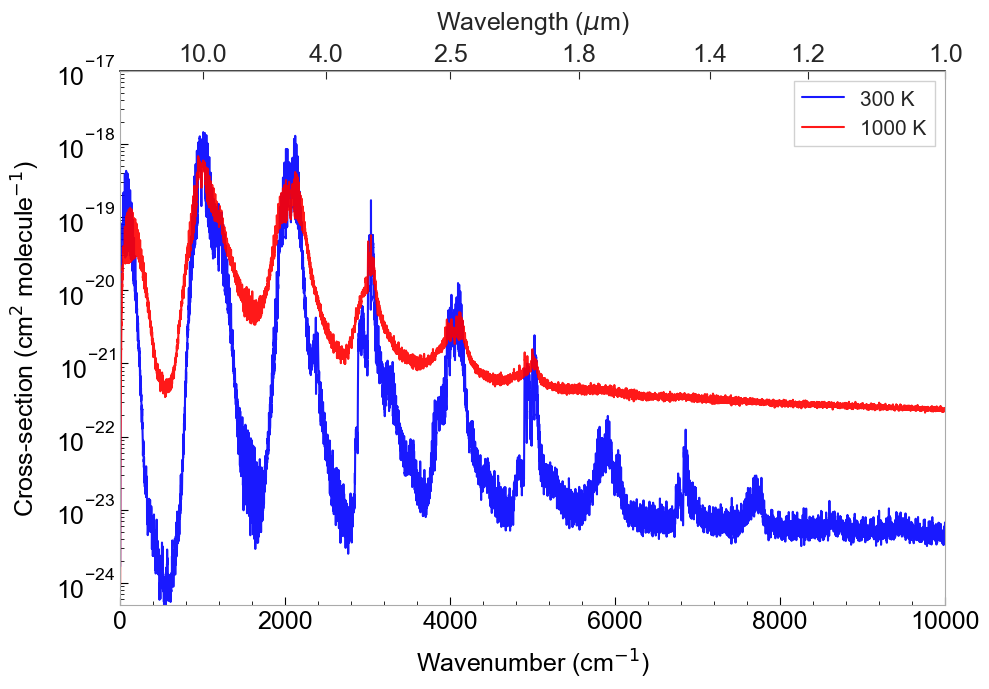

In [2]:
fig, ax = plt.subplots(figsize=(10, 7))
plt.style.use('seaborn-v0_8-white')  # No gridlines

# Plot (other colors, #2196F3, #8E24AA, #E53935)
ax.plot(wavenumber,  cross_sec,  color='blue', linewidth=1.5, label='300 K', alpha=0.9)
#ax.plot(wavenumber_, cross_sec_, color='darkorange', linewidth=1.5, label='500 K', alpha=0.9)
ax.plot(wavenumber_, cross_sec_, color='red', linewidth=1.5, label='1000 K', alpha=0.9)

# Log scale & axis limits
ax.set_yscale('log')
ax.set_xlim(0, 10000)
ax.set_ylim(0.5e-24, 1e-17)

# Primary x-axis (wavenumber)
ax.set_xlabel(r'Wavenumber (cm$^{-1}$)', fontsize=18, labelpad=10)
ax.set_ylabel(r'Cross-section (cm$^{2}$ molecule$^{-1}$)', fontsize=18, labelpad=10)
#ax.set_title('Absorption Cross-Sections', fontsize=16, fontweight='bold', pad=40)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=18, direction='in', length=6)
ax.tick_params(axis='both', which='minor', direction='in', length=3)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator(5))

# ── Secondary x-axis: wavelength (μm) ────────────────────────────────────────
# Wavelength (μm) = 10 000 / wavenumber (cm⁻¹); nonlinear so we set explicit ticks
ax_top = ax.secondary_xaxis('top')

# Choose round wavelength values (μm) that fall within xlim (0–5000 cm⁻¹)
wl_ticks_um = np.round(10000/np.arange(1000,20000,1500), decimals=1) # μm
wn_positions = 10000 / wl_ticks_um   # cm⁻¹ positions

ax_top.set_xticks(wn_positions)
ax_top.set_xticklabels([str(w) for w in wl_ticks_um], fontsize=18)
ax_top.set_xlabel(r'Wavelength ($\mu$m)', fontsize=18, labelpad=10)
ax_top.tick_params(which='major', direction='in', length=6)

# Legend
ax.legend(
    fontsize=15,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc',
    fancybox=False,
    loc='best'
)

# Subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#aaaaaa')
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.savefig('HPO_J0_J141_cross_sections.png', transparent=True, dpi=300, bbox_inches='tight')
#plt.savefig('HPO_J0_J40_cross_sections.eps', format='eps', bbox_inches='tight')
plt.show()

In [3]:
pf_data = pd.read_csv("pf_table.dat", skiprows=1, sep=r"\s+", index_col="J")
pf_data.columns = pf_data.columns.astype(float)
pf_data.columns.name = "Temperature"

print(pf_data.columns)
print(pf_data.iloc[0,0])

Index([1000.0, 1500.0, 2000.0, 2500.0, 3000.0], dtype='float64', name='Temperature')
67.4821


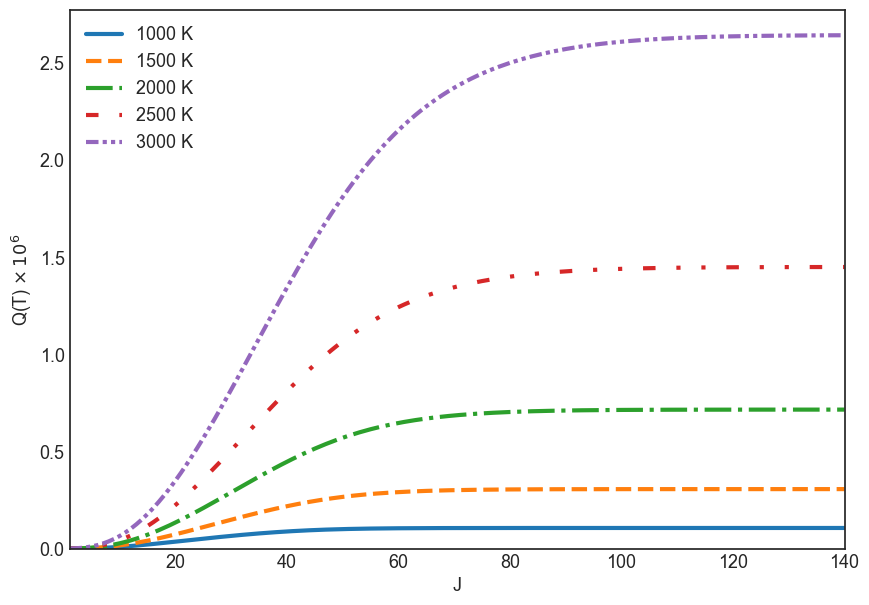

In [4]:
linestyles = ['-', 
              '--',
              '-.',
              (0, (3, 5, 1, 5, 1, 5)),
              (0, (3, 1, 1, 1, 1, 1))
            ]


pf_fig, pf_ax = plt.subplots(1,1, figsize=(10, 7))
idx = 0 
for temp in pf_data.columns:
    pf_ax.plot(pf_data.index, 
               pf_data[temp]/1e6, 
               linestyle = linestyles[idx],
               label=f"{int(temp)} K", 
               linewidth=3)
    idx += 1

pf_ax.set_xlim(1,140)
pf_ax.set_ylim(0, 1.05/1e6*pf_data.max().max())
pf_ax.tick_params(axis='both', labelsize=13)

pf_ax.set_xlabel('J', fontsize=13)
pf_ax.set_ylabel(r'Q(T) $\times\,10^6$', fontsize=13)
pf_ax.legend(fontsize=13)

plt.savefig('HPO_J0_J141_pf.png', transparent=True, dpi=300, bbox_inches='tight')

In [5]:
type(pf_data.max())

pandas.Series